# Silco Jupyter Smoke Test

This notebook defines Pydantic models locally, maps them into Silco diagrams, and then runs an advanced flow simulation. The architecture notation comes from the real Silco diagram backend, while the notebook output focuses on simulated traffic and flow metrics.


In [1]:
from collections import defaultdict, deque
from math import ceil
from typing import Literal

from IPython.display import SVG, display
from pydantic import BaseModel, Field

from silco import diagram, kernel

discovered = kernel.discover()
print('Discovered plugins:', [(p.category, p.name) for p in discovered])
print('Renderers:', kernel.names('renderers'))
print('Styles:', kernel.names('styles'))

Discovered plugins: [('renderers', 'pdf'), ('presenters', 'ipython'), ('styles', 'modern'), ('styles', 'uml')]
Renderers: ('svg', 'mermaid', 'pdf')
Styles: ('modern', 'uml')


## Define Notebook-Local Pydantic Models

In [2]:
NodeKind = Literal['actor', 'service', 'database', 'queue', 'cache', 'storage', 'external', 'component']


class ServiceModel(BaseModel):
    id: str
    label: str
    kind: NodeKind = 'service'
    group: str | None = None
    technology: str | None = None
    description: str | None = None
    line: int | None = None
    monthly_base_cost: float = 0.0
    cost_per_request: float = 0.0
    replicas: int = 1
    max_replicas: int = 6
    capacity_rps_per_replica: float = 100.0
    base_latency_ms: float = 20.0
    failure_rate: float = 0.0
    retry_multiplier: float = 0.0
    queue_decay: float = 0.0


class LinkModel(BaseModel):
    source: str
    target: str
    protocol: str | None = None
    label: str | None = None
    mode: Literal['connect', 'flow'] = 'connect'
    calls_per_request: float = 1.0
    latency_ms: float = 0.0
    loss_rate: float = 0.0


class ArchitectureModel(BaseModel):
    title: str
    direction: Literal['LR', 'RL', 'TB', 'BT'] = 'LR'
    groups: dict[str, str] = Field(default_factory=dict)
    services: list[ServiceModel]
    links: list[LinkModel]


class TrafficScenario(BaseModel):
    name: str
    entry_requests_per_second: dict[str, float]
    duration_steps: int = 24
    step_seconds: int = 300
    diurnal_amplitude: float = 0.25
    spike_step: int | None = None
    spike_multiplier: float = 1.0


## Create the Domain Model in the Notebook

In [3]:
commerce = ArchitectureModel(
    title='Global Commerce Platform',
    direction='LR',
    groups={
        'edge': 'Edge',
        'app': 'Application',
        'data': 'Data Plane',
    },
    services=[
        ServiceModel(id='user', label='Customer', kind='actor', line=0),
        ServiceModel(id='web', label='Web App', kind='service', group='edge', technology='Next.js', line=0, monthly_base_cost=45, capacity_rps_per_replica=70, base_latency_ms=22, failure_rate=0.01, retry_multiplier=0.01),
        ServiceModel(id='api', label='API Gateway', kind='service', group='edge', technology='Envoy', line=1, monthly_base_cost=55, capacity_rps_per_replica=90, base_latency_ms=12, failure_rate=0.005, retry_multiplier=0.02),
        ServiceModel(id='checkout', label='Checkout Service', kind='service', group='app', technology='Python', line=1, monthly_base_cost=80, capacity_rps_per_replica=60, base_latency_ms=45, failure_rate=0.02, retry_multiplier=0.04, cost_per_request=0.0015),
        ServiceModel(id='payments', label='Payments Provider', kind='external', line=1, base_latency_ms=90, failure_rate=0.03, retry_multiplier=0.08, cost_per_request=0.025),
        ServiceModel(id='queue', label='Order Events', kind='queue', group='data', technology='Kafka', line=2, monthly_base_cost=65, capacity_rps_per_replica=150, base_latency_ms=15, queue_decay=0.65, cost_per_request=0.0002),
        ServiceModel(id='orders', label='Orders DB', kind='database', group='data', technology='Postgres', line=2, monthly_base_cost=120, capacity_rps_per_replica=80, base_latency_ms=30, failure_rate=0.01, cost_per_request=0.0004),
    ],
    links=[
        LinkModel(source='user', target='web', protocol='HTTPS', latency_ms=10),
        LinkModel(source='web', target='api', protocol='HTTPS', latency_ms=6),
        LinkModel(source='api', target='checkout', protocol='gRPC', latency_ms=4),
        LinkModel(source='checkout', target='payments', label='authorize', protocol='HTTPS', latency_ms=20, loss_rate=0.02),
        LinkModel(source='checkout', target='orders', label='persist', protocol='SQL', latency_ms=8),
        LinkModel(source='checkout', target='queue', mode='flow', label='publish', protocol='Kafka', latency_ms=5),
    ],
)

scenario = TrafficScenario(
    name='holiday-peak',
    entry_requests_per_second={'web': 52},
    duration_steps=30,
    step_seconds=300,
    diurnal_amplitude=0.35,
    spike_step=18,
    spike_multiplier=2.1,
)

commerce

ArchitectureModel(title='Global Commerce Platform', direction='LR', groups={'edge': 'Edge', 'app': 'Application', 'data': 'Data Plane'}, services=[ServiceModel(id='user', label='Customer', kind='actor', group=None, technology=None, description=None, line=0, monthly_base_cost=0.0, cost_per_request=0.0, replicas=1, max_replicas=6, capacity_rps_per_replica=100.0, base_latency_ms=20.0, failure_rate=0.0, retry_multiplier=0.0, queue_decay=0.0), ServiceModel(id='web', label='Web App', kind='service', group='edge', technology='Next.js', description=None, line=0, monthly_base_cost=45.0, cost_per_request=0.0, replicas=1, max_replicas=6, capacity_rps_per_replica=70.0, base_latency_ms=22.0, failure_rate=0.01, retry_multiplier=0.01, queue_decay=0.0), ServiceModel(id='api', label='API Gateway', kind='service', group='edge', technology='Envoy', description=None, line=1, monthly_base_cost=55.0, cost_per_request=0.0, replicas=1, max_replicas=6, capacity_rps_per_replica=90.0, base_latency_ms=12.0, failu

## Map Notebook Models to a Properly Notated Diagram

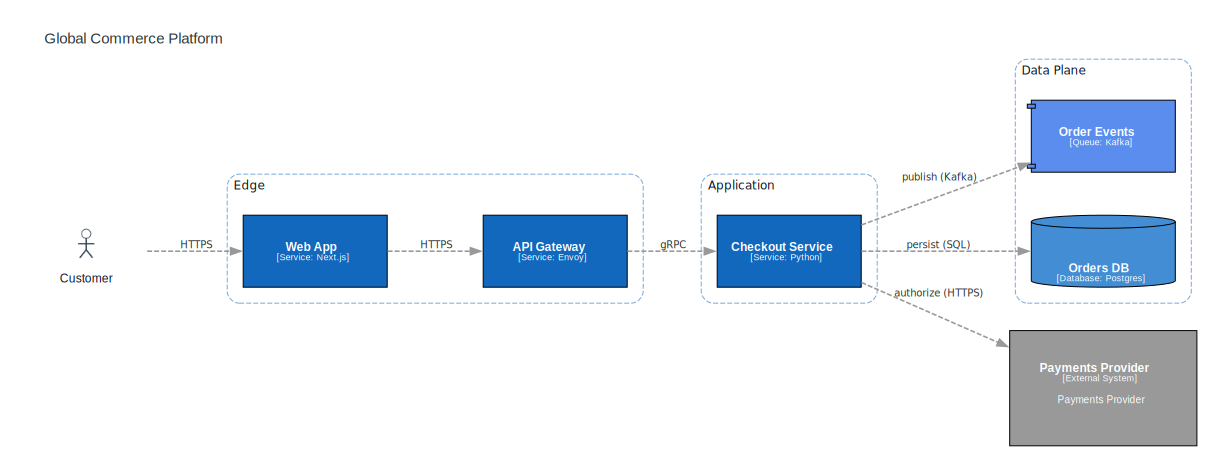

flowchart LR
    subgraph edge["Edge"]
    web["Web App"]
    api["API Gateway"]
    end
    subgraph app["Application"]
    checkout["Checkout Service"]
    end
    subgraph data["Data Plane"]
    queue[("Order Events")]
    orders[("Orders DB")]
    end
    user(["Customer"])
    payments{"Payments Provider"}
    user -->|HTTPS| web
    web -->|HTTPS| api
    api -->|gRPC| checkout
    checkout -->|authorize (HTTPS)| payments
    checkout -->|persist (SQL)| orders
    checkout -->|publish (Kafka)| queue


In [4]:
def to_silco_diagram(model: ArchitectureModel):
    d = diagram(model.title, direction=model.direction)
    for group_id, label in model.groups.items():
        d.group(group_id, label=label)
    for service in model.services:
        metadata = {}
        if service.technology:
            metadata['technology'] = service.technology
        if service.line is not None:
            metadata['line'] = service.line
        d.node(
            service.id,
            service.label,
            kind=service.kind,
            group=service.group,
            description=service.description,
            **metadata,
        )
    for link in model.links:
        if link.mode == 'flow':
            d.flow(link.source, link.target, link.label, protocol=link.protocol, calls_per_request=link.calls_per_request)
        else:
            d.connect(link.source, link.target, link.label, protocol=link.protocol, calls_per_request=link.calls_per_request)
    return d


commerce_diagram = to_silco_diagram(commerce)
try:
    display(SVG(commerce_diagram.to_svg(style='modern')))
except RuntimeError as exc:
    print('SVG backend unavailable in this kernel:', exc)
print(commerce_diagram.to_mermaid())

## Advanced Flow Simulation

In [5]:
def topology(model: ArchitectureModel):
    indegree = {service.id: 0 for service in model.services}
    outgoing = defaultdict(list)
    for link in model.links:
        outgoing[link.source].append(link)
        indegree[link.target] += 1
    queue = deque([service_id for service_id, count in indegree.items() if count == 0])
    order = []
    while queue:
        current = queue.popleft()
        order.append(current)
        for link in outgoing[current]:
            indegree[link.target] -= 1
            if indegree[link.target] == 0:
                queue.append(link.target)
    if len(order) != len(model.services):
        raise ValueError('Simulation requires an acyclic graph.')
    return order, outgoing


def demand_multiplier(step: int, total_steps: int, scenario: TrafficScenario) -> float:
    diurnal = 1.0 + scenario.diurnal_amplitude * sin(2 * pi * step / max(total_steps, 1))
    spike = scenario.spike_multiplier if scenario.spike_step == step else 1.0
    return max(0.1, diurnal * spike)


def simulate_advanced(model: ArchitectureModel, scenario: TrafficScenario):
    order, outgoing = topology(model)
    services = {service.id: service for service in model.services}
    async_backlog = defaultdict(float)
    timeline = []
    per_service_totals = defaultdict(lambda: defaultdict(float))
    per_edge_totals = defaultdict(float)

    for step in range(scenario.duration_steps):
        multiplier = demand_multiplier(step, scenario.duration_steps, scenario)
        incoming = defaultdict(float)
        edge_flows = {}
        service_frame = {}

        for entry_id, base_rps in scenario.entry_requests_per_second.items():
            incoming[entry_id] += base_rps * multiplier
        for service_id, backlog in list(async_backlog.items()):
            incoming[service_id] += backlog

        next_backlog = defaultdict(float)

        for service_id in order:
            service = services[service_id]
            requested_rps = incoming[service_id]
            capacity = service.replicas * service.capacity_rps_per_replica
            served_rps = min(requested_rps, capacity)
            saturated_rps = max(0.0, requested_rps - capacity)
            failures_rps = served_rps * service.failure_rate
            retries_rps = failures_rps * service.retry_multiplier
            successful_rps = max(0.0, served_rps - failures_rps)
            utilization = served_rps / capacity if capacity else 0.0
            latency_ms = service.base_latency_ms * (1.0 + utilization ** 2.2)
            required_replicas = max(1, ceil(requested_rps / service.capacity_rps_per_replica)) if requested_rps else 1
            recommended_replicas = min(service.max_replicas, max(service.replicas, required_replicas))
            step_requests = successful_rps * scenario.step_seconds
            step_cost = service.monthly_base_cost / (30 * 24 * 3600 / scenario.step_seconds) + service.cost_per_request * step_requests

            service_frame[service_id] = {
                'label': service.label,
                'requested_rps': requested_rps,
                'served_rps': served_rps,
                'successful_rps': successful_rps,
                'failures_rps': failures_rps,
                'saturated_rps': saturated_rps,
                'retries_rps': retries_rps,
                'latency_ms': latency_ms,
                'utilization': utilization,
                'replicas': service.replicas,
                'recommended_replicas': recommended_replicas,
                'step_cost': step_cost,
            }

            per_service_totals[service_id]['requests'] += step_requests
            per_service_totals[service_id]['cost'] += step_cost
            per_service_totals[service_id]['failures'] += failures_rps * scenario.step_seconds
            per_service_totals[service_id]['saturated'] += saturated_rps * scenario.step_seconds

            forwarded_budget = successful_rps + retries_rps
            for link in outgoing[service_id]:
                flow_rps = forwarded_budget * link.calls_per_request
                flow_rps = flow_rps * (1.0 - link.loss_rate)
                edge_key = (link.source, link.target)
                edge_flows[edge_key] = {
                    'rps': flow_rps,
                    'mode': link.mode,
                    'protocol': link.protocol or '',
                    'label': link.label or '',
                    'latency_ms': link.latency_ms,
                }
                per_edge_totals[edge_key] += flow_rps * scenario.step_seconds
                if link.mode == 'flow':
                    decay = 1.0 - services[link.target].queue_decay
                    next_backlog[link.target] += flow_rps * decay
                else:
                    incoming[link.target] += flow_rps

        async_backlog = next_backlog
        timeline.append({
            'step': step,
            'multiplier': multiplier,
            'services': service_frame,
            'edges': edge_flows,
        })

    service_summary = []
    for service in model.services:
        totals = per_service_totals[service.id]
        peak = max(frame['services'][service.id]['requested_rps'] for frame in timeline)
        p95_latency = sorted(frame['services'][service.id]['latency_ms'] for frame in timeline)[int(0.95 * (len(timeline) - 1))]
        service_summary.append({
            'service': service.label,
            'peak_requested_rps': round(peak, 2),
            'total_requests': round(totals['requests'], 0),
            'failed_requests': round(totals['failures'], 0),
            'saturated_requests': round(totals['saturated'], 0),
            'p95_latency_ms': round(p95_latency, 2),
            'total_cost': round(totals['cost'], 2),
        })

    edge_summary = []
    for link in model.links:
        edge_key = (link.source, link.target)
        peak_edge_rps = max(frame['edges'].get(edge_key, {}).get('rps', 0.0) for frame in timeline)
        edge_summary.append({
            'source': link.source,
            'target': link.target,
            'mode': link.mode,
            'protocol': link.protocol,
            'peak_rps': round(peak_edge_rps, 2),
            'total_messages': round(per_edge_totals[edge_key], 0),
        })

    return {
        'timeline': timeline,
        'service_summary': service_summary,
        'edge_summary': edge_summary,
        'scenario': scenario,
        'model': model,
    }

## Run the Simulation and Show Explicit Flows

In [6]:
sim = simulate_advanced(commerce, scenario)
service_summary = sorted(sim['service_summary'], key=lambda row: row['total_cost'], reverse=True)
edge_summary = sorted(sim['edge_summary'], key=lambda row: row['total_messages'], reverse=True)

print('Scenario:', scenario.name)
print('Steps:', scenario.duration_steps)
print('Total estimated cost:', round(sum(row['total_cost'] for row in service_summary), 2))
service_summary

NameError: name 'sin' is not defined

In [ ]:
print('Per-link flow summary')
edge_summary